# Dark-field estimation and regularisation tuning

This notebook covers:

1. **When and why** to enable dark-field estimation.
2. **Auto-tuning vs. manual override** of the regularisation weights `l_s` and `l_d`.
3. How to read `prepare()` diagnostics to decide whether auto-tuning is sufficient.
4. A sensitivity sweep showing how `l_s` / `l_d` affect the estimated fields.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from linum_basic import BaSiC
from linum_basic.data import load_sample_image

plt.rcParams.update(
    {
        "figure.dpi": 150,
        "figure.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

## 1. Synthetic stack with dark-field

We create a shaded stack that includes a non-zero dark offset — the signal
present even without illumination (detector read noise, fluorescence
background, etc.).

In [2]:
TILE = 64
rng = np.random.default_rng(42)

# Ground-truth fields
y, x = np.mgrid[-1 : 1 : TILE * 1j, -1 : 1 : TILE * 1j]  # type: ignore[misc]
gt_flat = (0.5 + 0.5 * np.exp(-1.5 * (x**2 + y**2))).astype(np.float32)
gt_flat /= float(gt_flat.mean())
gt_dark = (0.08 * np.ones((TILE, TILE))).astype(np.float32)  # noticeable dark offset

# Tile the bundled sample image
source = load_sample_image().astype(np.float32) / 255.0
h, w = source.shape
tiles = [source[r * TILE : (r + 1) * TILE, c * TILE : (c + 1) * TILE] for r in range(h // TILE) for c in range(w // TILE)]
brightness = rng.uniform(0.3, 0.9, (len(tiles), 1, 1)).astype(np.float32)
clean = np.stack(tiles).astype(np.float32)
shaded = clean * brightness * gt_flat + gt_dark

print(f"Stack: {shaded.shape}  dark mean: {gt_dark.mean():.3f}  flat mean: {gt_flat.mean():.3f}")

Stack: (704, 64, 64)  dark mean: 0.080  flat mean: 1.000


## 2. Effect of `estimate_darkfield`

Compare two models: one that ignores the dark-field and one that estimates it.

In [3]:
def run_model(estimate_darkfield: bool) -> BaSiC:
    """Fit BaSiC with or without dark-field estimation."""
    m = BaSiC(shaded, estimate_darkfield=estimate_darkfield)
    m.working_size = 64
    return m.run()


model_nodf = run_model(estimate_darkfield=False)
model_df = run_model(estimate_darkfield=True)

print(f"Without dark-field  — flat mean: {model_nodf.get_flatfield().mean():.4f}")
print(f"With dark-field     — flat mean: {model_df.get_flatfield().mean():.4f}")
print(f"With dark-field     — dark mean: {model_df.get_darkfield().mean():.6f}  (gt: {gt_dark.mean():.6f})")

Without dark-field  — flat mean: 1.0000
With dark-field     — flat mean: 1.0000
With dark-field     — dark mean: 0.080000  (gt: 0.080000)


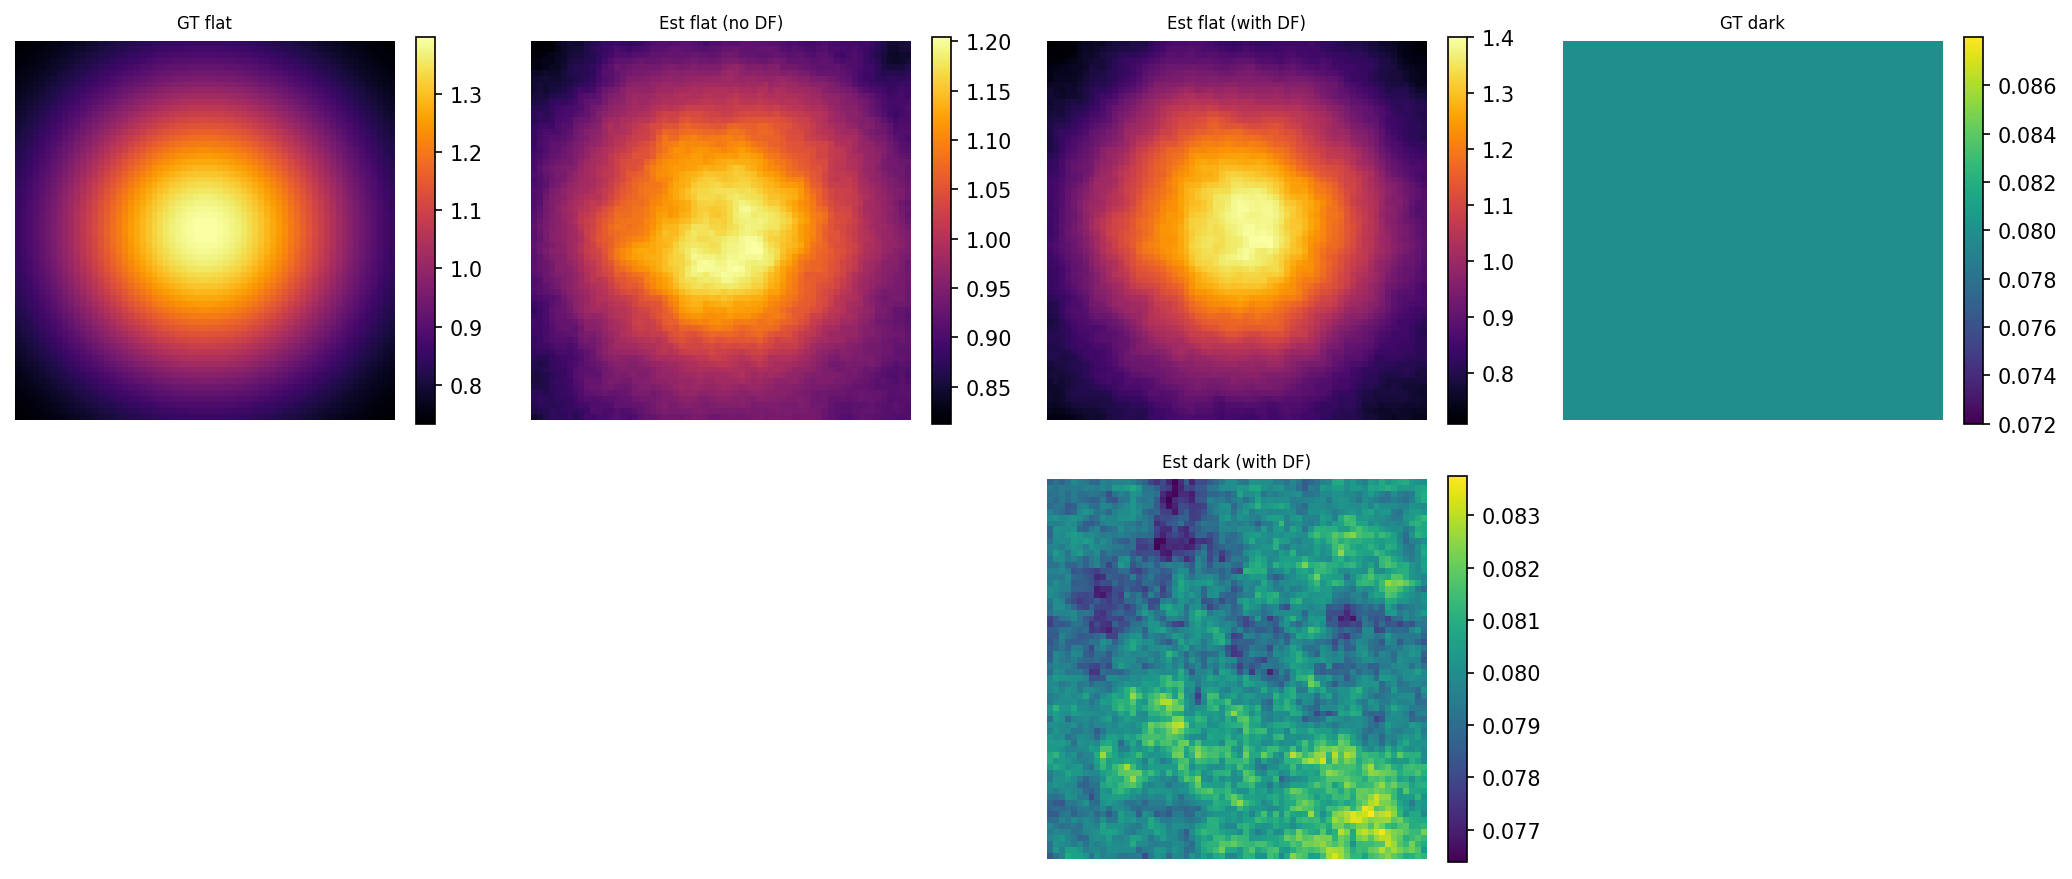

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
titles = ["GT flat", "Est flat (no DF)", "Est flat (with DF)", "GT dark", "", "", "Est dark (with DF)", ""]

images = [
    (gt_flat, "inferno"),
    (model_nodf.get_flatfield(), "inferno"),
    (model_df.get_flatfield(), "inferno"),
    (gt_dark, "viridis"),
    (None, None),
    (None, None),
    (model_df.get_darkfield(), "viridis"),
    (None, None),
]

for ax, (img, cmap), title in zip(axes.ravel(), images, titles + [""] * 8, strict=False):
    if img is not None:
        im = ax.imshow(img, cmap=cmap)
        plt.colorbar(im, ax=ax, fraction=0.046)
        ax.set_title(title, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Auto-tuning diagnostics

After calling `prepare()`, inspect the auto-tuned `l_s` and `l_d` before
running the solver.  This is useful to sanity-check the dataset and decide
whether manual override is needed.

In [5]:
model = BaSiC(shaded, estimate_darkfield=True)
model.working_size = 64
model.prepare()

print("dct_sum (energy proxy) : auto-computed internally")
print(f"l_s (flat-field reg)   : {model.l_s:.6f}")
print(f"l_d (dark-field reg)   : {model.l_d:.6f}")
print()
print("Rule of thumb:")
print("  l_s ≈ dct_energy / 800   → fine for moderate vignette")
print("  l_d ≈ dct_energy / 2000  → fine for low dark-field")
print()
print("If the estimated flat-field is too smooth → decrease l_s")
print("If it is too noisy          → increase l_s")

dct_sum (energy proxy) : auto-computed internally
l_s (flat-field reg)   : 0.127699
l_d (dark-field reg)   : 0.051080

Rule of thumb:
  l_s ≈ dct_energy / 800   → fine for moderate vignette
  l_d ≈ dct_energy / 2000  → fine for low dark-field

If the estimated flat-field is too smooth → decrease l_s
If it is too noisy          → increase l_s


## 4. Manual override of `l_s` and `l_d`

Set `l_s` / `l_d` **after** `prepare()` (which would overwrite them) to
force specific values, or pass them directly to the `BaSiC` constructor
and skip `prepare()`.

Auto l_s : 0.127699
Manual   : 0.031925  (after override)


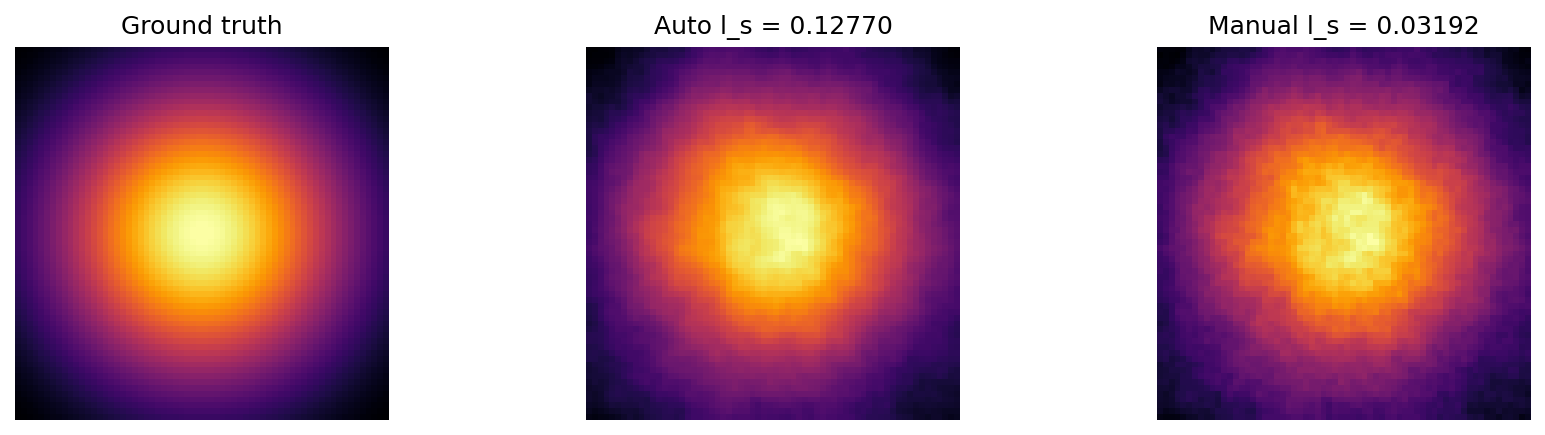

In [6]:
# Option A: prepare() then override
model_manual = BaSiC(shaded, estimate_darkfield=True)
model_manual.working_size = 64
model_manual.prepare()
auto_ls = model_manual.l_s
model_manual.l_s = auto_ls * 0.25  # 4x less smoothing → sharper flat-field
model_manual.run()

print(f"Auto l_s : {auto_ls:.6f}")
print(f"Manual   : {model_manual.l_s:.6f}  (after override)")

# Compare the two flat-fields side by side
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
model.run()  # finish the auto-tuned model

axes[0].imshow(gt_flat, cmap="inferno")
axes[0].set_title("Ground truth")
axes[1].imshow(model.get_flatfield(), cmap="inferno")
axes[1].set_title(f"Auto l_s = {model.l_s:.5f}")
axes[2].imshow(model_manual.get_flatfield(), cmap="inferno")
axes[2].set_title(f"Manual l_s = {model_manual.l_s:.5f}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Regularisation sensitivity sweep

Sweep `l_s` over one decade and plot the estimated flat-field correlation
against the ground truth.  The sweet spot is where correlation is maximised
without over-smoothing.

  l_s = 0.01277  (×0.10)  → Pearson r = 0.9801
  l_s = 0.03192  (×0.25)  → Pearson r = 0.9816
  l_s = 0.06385  (×0.50)  → Pearson r = 0.9834
  l_s = 0.12770  (×1.00)  → Pearson r = 0.9859
  l_s = 0.25540  (×2.00)  → Pearson r = 0.9884
  l_s = 0.51080  (×4.00)  → Pearson r = 0.9911
  l_s = 1.02159  (×8.00)  → Pearson r = 0.9943


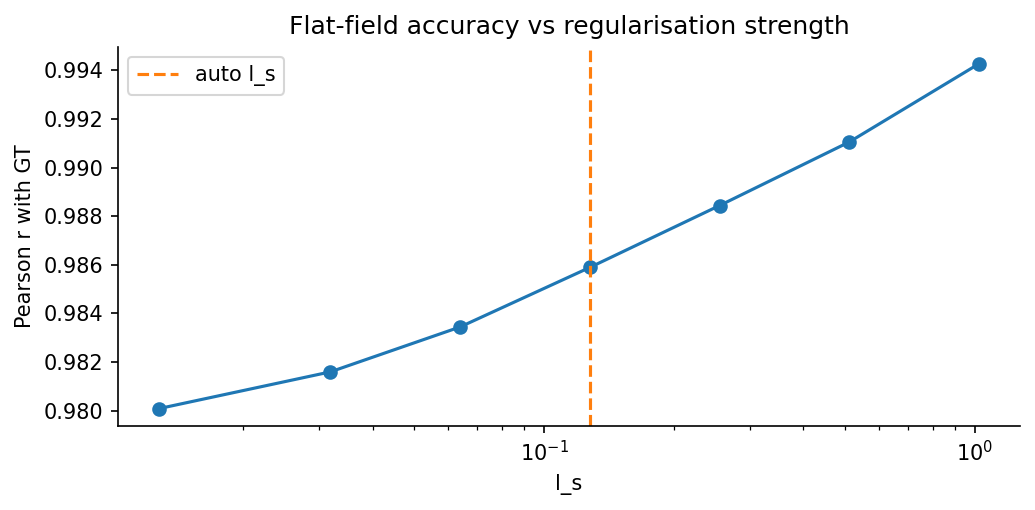

In [7]:
# Re-use prepare()'s auto l_s as the reference scale
ref = BaSiC(shaded)
ref.working_size = 64
ref.prepare()
base_ls = ref.l_s

multipliers = [0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
corrs = []

for mult in multipliers:
    m = BaSiC(shaded)
    m.working_size = 64
    m.prepare()
    m.l_s = base_ls * mult
    m.run()
    r = float(np.corrcoef(gt_flat.ravel(), m.get_flatfield().ravel())[0, 1])
    corrs.append(r)
    print(f"  l_s = {m.l_s:.5f}  (x{mult:.2f})  → Pearson r = {r:.4f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogx([base_ls * m for m in multipliers], corrs, "o-")
ax.axvline(base_ls, color="C1", linestyle="--", label="auto l_s")
ax.set_xlabel("l_s")
ax.set_ylabel("Pearson r with GT")
ax.set_title("Flat-field accuracy vs regularisation strength")
ax.legend()
plt.tight_layout()
plt.show()

## 6. The `epsilon` stability constant

`epsilon` prevents division by zero during reweighting.  Smaller values
allow more aggressive sparsity; larger values are more stable on
low-contrast stacks.

In [8]:
for eps in [0.01, 0.1, 0.5, 1.0]:
    m = BaSiC(shaded)
    m.working_size = 64
    m.epsilon = eps
    m.run()
    r = float(np.corrcoef(gt_flat.ravel(), m.get_flatfield().ravel())[0, 1])
    print(f"  epsilon = {eps:.2f}  → flat Pearson r = {r:.4f}")

  epsilon = 0.01  → flat Pearson r = 0.9781
  epsilon = 0.10  → flat Pearson r = 0.9859
  epsilon = 0.50  → flat Pearson r = 0.9901
  epsilon = 1.00  → flat Pearson r = 0.9907


## Next steps

* **Mosaic pipelines** — `MosaicGrid`, `fit_mosaic()`, seam metrics, and
  Optuna-based automated tuning: see the [Mosaic and seams](03_mosaic_and_seams.ipynb) notebook.
* **Advanced** — GPU backend, parallel z-levels, zarr I/O: see the
  [Advanced](04_advanced.ipynb) notebook.